# Global Layoffs Analysis (2020–2025)

## Objective
This project analyses global layoffs data to uncover trends across industries, geographies, and company stages. The goal is to generate actionable business insights and understand the drivers behind workforce reductions.

## Dataset
Source: Layoffs.fyi (via Kaggle)

## Key Questions
- Which industries experienced the most layoffs?
- Which countries were most affected?
- When did layoffs peak?
- What factors (funding, stage, industry) influence layoffs?

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("layoffs.csv")

df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,PowerSchool,Sacramento,NaN,12/12/2025,NaN,Education,https://www.bizjournals.com/sacramento/news/20...,Acquired,31.0,United States,12/15/2025
1,Believer Meats,"Jerusalem, Non-U.S.",NaN,12/11/2025,NaN,Food,https://www.calcalistech.com/ctechnews/article...,Series B,389.0,Israel,12/12/2025
2,EyeEm,"Berlin, Non-U.S.",NaN,12/11/2025,1.00,Other,https://petapixel.com/2025/12/11/eyeem-is-shut...,Acquired,24.0,Germany,12/12/2025
3,Lusha,Boston,24.0,12/10/2025,0.08,Sales,https://www.calcalistech.com/ctechnews/article...,Series B,245.0,United States,12/12/2025
4,Tenstorrent,"Toronto, Non-U.S.",80.0,12/9/2025,0.07,Hardware,https://www.eetimes.com/layoffs-at-tenstorrent...,Series D,1000.0,Canada,12/12/2025


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4248
Number of columns: 11


## Data Inspection

We begin by examining the structure, data types, and missing values to understand data quality before cleaning.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4248 non-null   object 
 1   location             4247 non-null   object 
 2   total_laid_off       2778 non-null   float64
 3   date                 4248 non-null   object 
 4   percentage_laid_off  2686 non-null   float64
 5   industry             4246 non-null   object 
 6   source               4245 non-null   object 
 7   stage                4243 non-null   object 
 8   funds_raised         3766 non-null   float64
 9   country              4246 non-null   object 
 10  date_added           4248 non-null   object 
dtypes: float64(3), object(8)
memory usage: 365.2+ KB


In [5]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,2778.000000,2686.000000,3766.000000
mean,288.700144,0.294735,827.375384
std,1003.087475,0.304203,4565.066634
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,53.000000
50%,87.000000,0.180000,170.500000
75%,200.000000,0.330000,479.000000
max,22000.000000,1.000000,121900.000000


In [6]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1470
date                      0
percentage_laid_off    1562
industry                  2
source                    3
stage                     5
funds_raised            482
country                   2
date_added                0
dtype: int64

### Initial Observations

- Some columns contain missing values (e.g., percentage_laid_off, total_laid_off, funds_raised_millions)
- Date column needs to be converted to a datetime format
- Data appears structured and suitable for analysis

## Data Cleaning

In this step, we:
- Drop empty column rows
- Handle missing values
- Convert data types
- Remove duplicates
- Standardise fields

In [7]:
df = df.dropna(subset=["total_laid_off"])

In [8]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
df.isnull().sum()

company                  0
location                 0
total_laid_off           0
date                     0
percentage_laid_off    868
industry                 1
source                   0
stage                    1
funds_raised           280
country                  1
date_added               0
dtype: int64

In [10]:
# percentage_laid_off can remain (not always available)
# funds_raised_millions → fill with 0 (safe assumption for analysis)

df["funds_raised"] = df["funds_raised"].fillna(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df["country"] = df["country"].str.strip()
df["industry"] = df["industry"].str.strip()

In [13]:
df.isnull().sum()

company                  0
location                 0
total_laid_off           0
date                     0
percentage_laid_off    868
industry                 1
source                   0
stage                    1
funds_raised             0
country                  1
date_added               0
dtype: int64

In [14]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2778
Number of columns: 11


## Feature Engineering

We extract additional features such as year and month to support time-based analysis.

In [15]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [16]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,year,month
3,Lusha,Boston,24.0,2025-12-10,0.08,Sales,https://www.calcalistech.com/ctechnews/article...,Series B,245.0,United States,12/12/2025,2025,12
4,Tenstorrent,"Toronto, Non-U.S.",80.0,2025-12-09,0.07,Hardware,https://www.eetimes.com/layoffs-at-tenstorrent...,Series D,1000.0,Canada,12/12/2025,2025,12
5,VSCO,SF Bay Area,24.0,2025-12-09,NaN,Consumer,https://techcrunch.com/2025/12/09/vsco-lays-of...,Series B,90.0,United States,12/10/2025,2025,12
7,Mobileye,"Jerusalem, Non-U.S.",200.0,2025-12-08,0.04,Transportation,https://www.calcalistech.com/ctechnews/article...,Post-IPO,2100.0,Israel,12/8/2025,2025,12
8,Payoneer,New York City,60.0,2025-12-08,0.06,Finance,https://www.calcalistech.com/ctechnews/article...,Post-IPO,0.0,United States,12/8/2025,2025,12


In [17]:
df["layoff_size"] = pd.cut(
    df["total_laid_off"],
    bins=[0, 100, 1000, 10000, np.inf],
    labels=["Small", "Medium", "Large", "Massive"]
)

df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,year,month,layoff_size
3,Lusha,Boston,24.0,2025-12-10,0.08,Sales,https://www.calcalistech.com/ctechnews/article...,Series B,245.0,United States,12/12/2025,2025,12,Small
4,Tenstorrent,"Toronto, Non-U.S.",80.0,2025-12-09,0.07,Hardware,https://www.eetimes.com/layoffs-at-tenstorrent...,Series D,1000.0,Canada,12/12/2025,2025,12,Small
5,VSCO,SF Bay Area,24.0,2025-12-09,NaN,Consumer,https://techcrunch.com/2025/12/09/vsco-lays-of...,Series B,90.0,United States,12/10/2025,2025,12,Small
7,Mobileye,"Jerusalem, Non-U.S.",200.0,2025-12-08,0.04,Transportation,https://www.calcalistech.com/ctechnews/article...,Post-IPO,2100.0,Israel,12/8/2025,2025,12,Medium
8,Payoneer,New York City,60.0,2025-12-08,0.06,Finance,https://www.calcalistech.com/ctechnews/article...,Post-IPO,0.0,United States,12/8/2025,2025,12,Small


In [20]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2778
Number of columns: 14


## Exploratory Data Analysis (EDA)

This section explores patterns and trends in global layoffs across time, industries, countries, and company characteristics.

The goal is to identify key drivers and patterns behind layoffs.

### Layoffs Over Time

We analyse how layoffs have evolved over time to identify peak periods and trends.

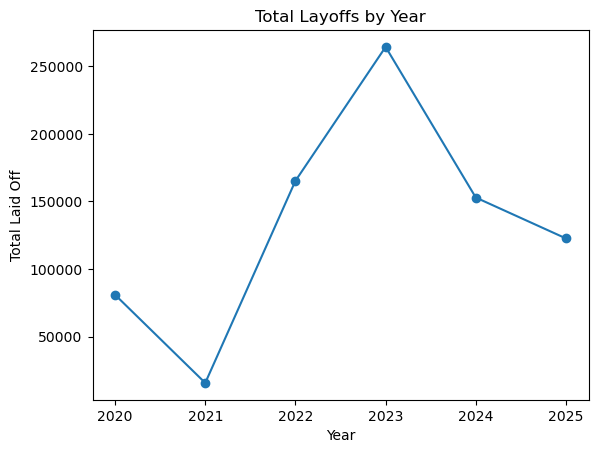

In [21]:
import matplotlib.pyplot as plt

layoffs_by_year = df.groupby("year")["total_laid_off"].sum()

layoffs_by_year.plot(kind="line", marker="o")
plt.title("Total Layoffs by Year")
plt.xlabel("Year")
plt.ylabel("Total Laid Off")
plt.show()

Layoffs peaked in 2023, indicating a period of significant workforce reduction, possibly driven by economic downturn or post-pandemic corrections.

### Layoffs by Industry

We analyse which industries were most affected by layoffs.

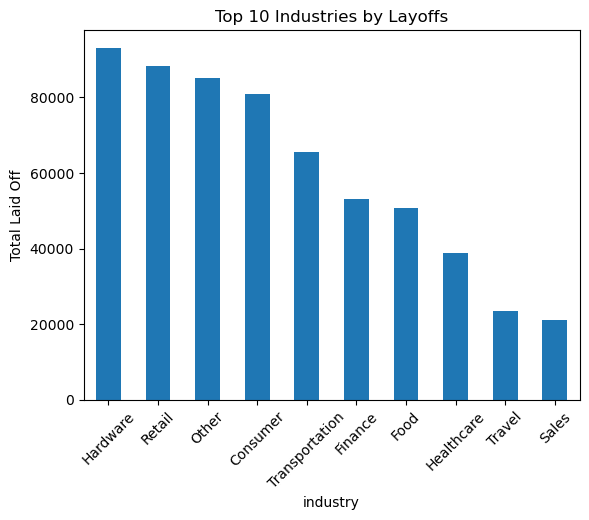

In [22]:
industry_layoffs = df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False)

industry_layoffs.head(10).plot(kind="bar")
plt.title("Top 10 Industries by Layoffs")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

The Hardware sector experienced the highest layoffs, suggesting structural changes or demand shifts within the sector.

### Layoffs by Country

We analyse the geographic distribution of layoffs.

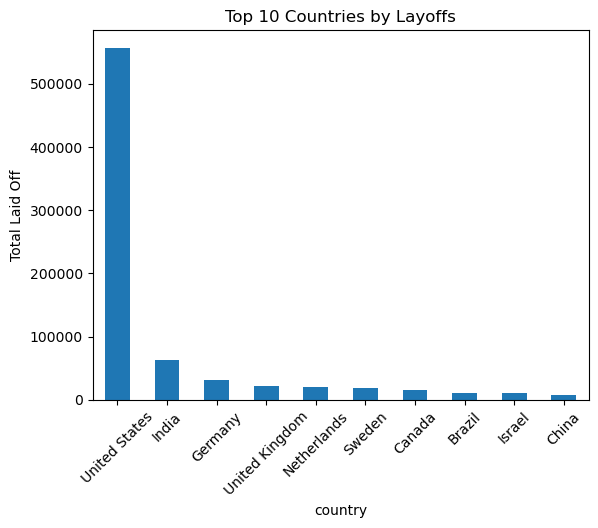

In [23]:
country_layoffs = df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False)

country_layoffs.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Layoffs")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

Layoffs are heavily concentrated in the United States, indicating higher exposure to economic or industry-specific shocks.

### Top Companies by Layoffs

We identify companies with the highest workforce reductions.

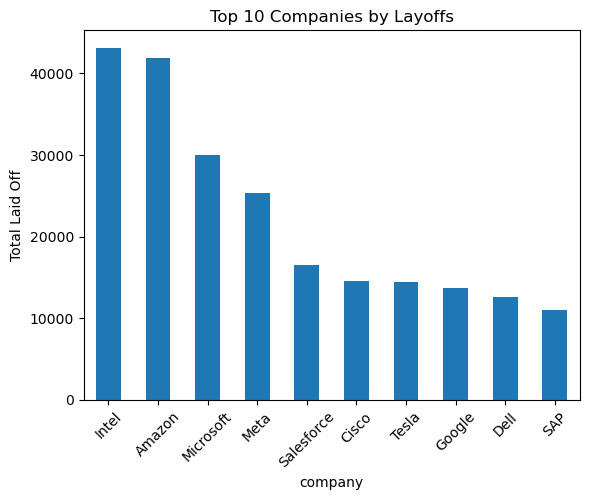

In [24]:
company_layoffs = df.groupby("company")["total_laid_off"].sum().sort_values(ascending=False)

company_layoffs.head(10).plot(kind="bar")
plt.title("Top 10 Companies by Layoffs")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

### Layoff Severity Distribution

We analyse the distribution of layoffs by size category.

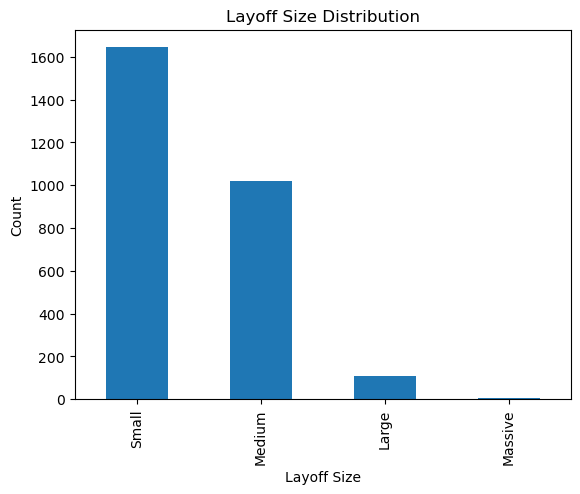

In [25]:
df["layoff_size"].value_counts().plot(kind="bar")
plt.title("Layoff Size Distribution")
plt.xlabel("Layoff Size")
plt.ylabel("Count")
plt.show()

Most layoffs fall within the small (0-100) range, while fewer companies conducted large-scale layoffs.

### Funding vs Layoffs

We analyse whether companies with higher funding experienced more layoffs.

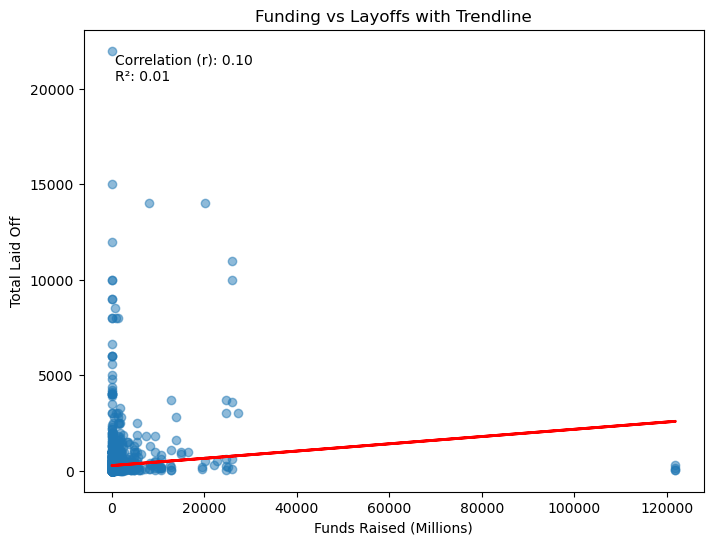

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Remove missing values for clean plotting
df_clean = df[["funds_raised", "total_laid_off"]].dropna()

x = df_clean["funds_raised"]
y = df_clean["total_laid_off"]

# Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5)

# Fit trendline (linear regression)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Calculate correlation coefficient
corr = np.corrcoef(x, y)[0,1]

# Calculate R-squared
r_squared = corr**2

# Titles and labels
plt.title("Funding vs Layoffs with Trendline")
plt.xlabel("Funds Raised (Millions)")
plt.ylabel("Total Laid Off")

# Annotate metrics on chart
plt.text(
    0.05, 0.95,
    f"Correlation (r): {corr:.2f}\nR²: {r_squared:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top'
)

plt.show()

There is a weak relationship between funding and layoffs, suggesting that even well-funded companies are not immune to workforce reductions.

### Monthly Layoff Trends

To better understand the dynamics of layoffs, we analyse trends at a monthly level rather than yearly.

This allows us to:
- Identify specific periods of intense layoffs
- Detect economic shocks or industry-wide corrections
- Observe recovery patterns over time

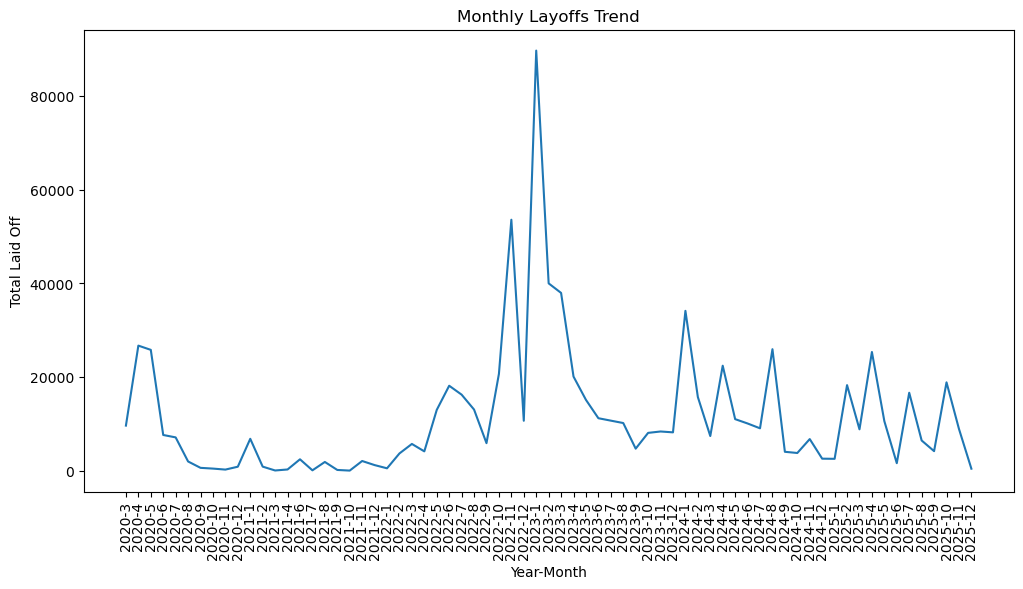

In [29]:
monthly_trend = df.groupby(["year", "month"])["total_laid_off"].sum().reset_index()

monthly_trend["year_month"] = monthly_trend["year"].astype(str) + "-" + monthly_trend["month"].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_trend["year_month"], monthly_trend["total_laid_off"])
plt.xticks(rotation=90)
plt.title("Monthly Layoffs Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Laid Off")
plt.show()

Layoffs occur in distinct waves rather than being evenly distributed over time. 
These spikes likely correspond to macroeconomic events such as funding slowdowns, inflationary pressure, or post-pandemic market corrections.

### Layoffs by Industry Over Time

This analysis examines how layoffs evolved across industries over time.

It helps to:
- Identify which industries were impacted first
- Understand sector-specific vulnerabilities
- Compare recovery patterns across industries

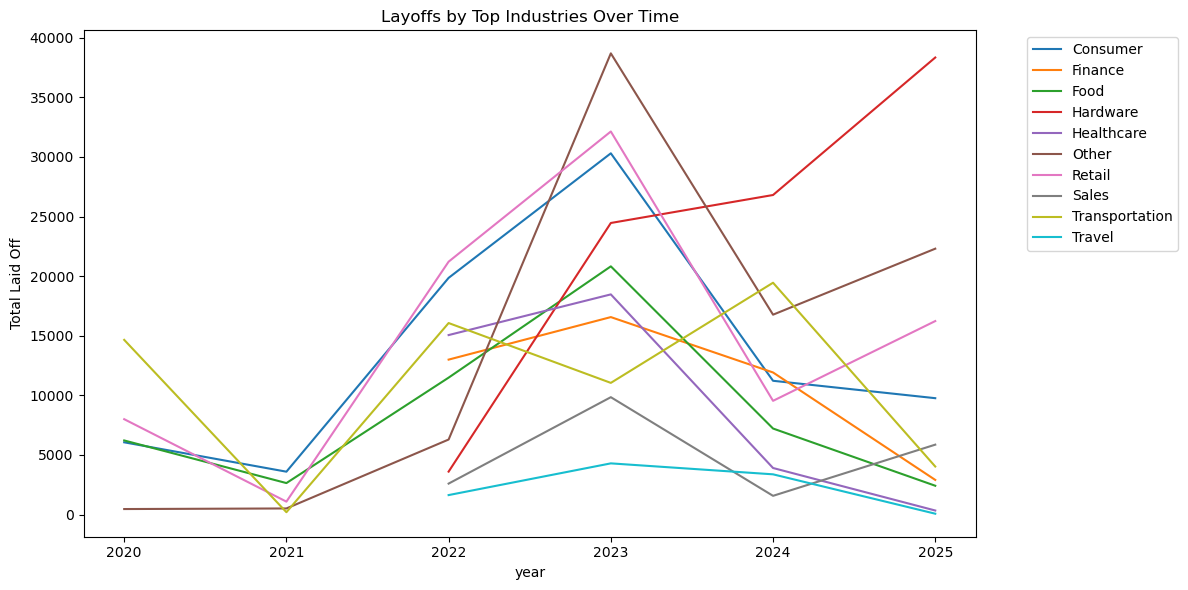

In [34]:
top_industries = df.groupby("industry")["total_laid_off"].sum().nlargest(10).index

filtered = df[df["industry"].isin(top_industries)]

industry_time = filtered.groupby(["year", "industry"])["total_laid_off"].sum().unstack()

plt.figure(figsize=(12,6))
industry_time.plot(ax=plt.gca())

plt.title("Layoffs by Top Industries Over Time")
plt.ylabel("Total Laid Off")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The top 10 different industries experienced layoffs at different times, suggesting that layoffs are not uniform across sectors.

### Industry Layoffs Across Top Countries

This analysis explores how layoffs are distributed across industries within major countries.

It helps to:
- Identify regional economic exposure
- Understand country-specific industry risks
- Compare structural differences across economies

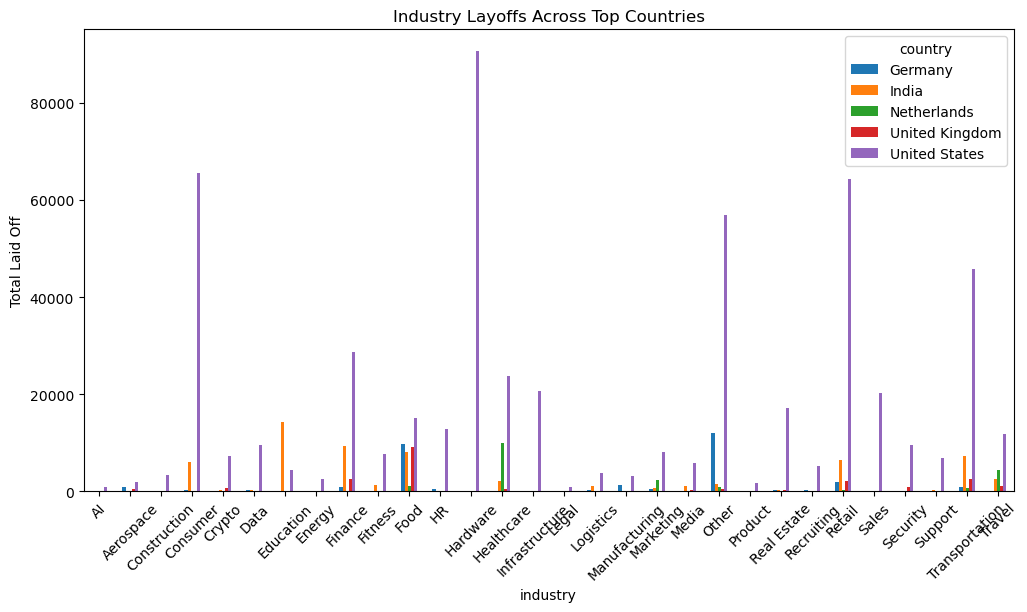

In [35]:
country_industry = df.groupby(["country", "industry"])["total_laid_off"].sum().reset_index()

top_countries = country_industry.groupby("country")["total_laid_off"].sum().nlargest(5).index

filtered = country_industry[country_industry["country"].isin(top_countries)]

pivot = filtered.pivot(index="industry", columns="country", values="total_laid_off")

pivot.plot(kind="bar", figsize=(12,6))
plt.title("Industry Layoffs Across Top Countries")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

Layoffs are concentrated in specific industries within certain countries, indicating that economic shocks are often sector-specific rather than economy-wide.

Countries with strong technology sectors tend to experience higher layoffs in those industries.

### Layoffs by Company Stage

This analysis examines layoffs across different company stages (e.g., Seed, Series A, IPO).

It helps to:
- Understand which types of companies are most vulnerable
- Identify whether layoffs are driven by early-stage or mature firms

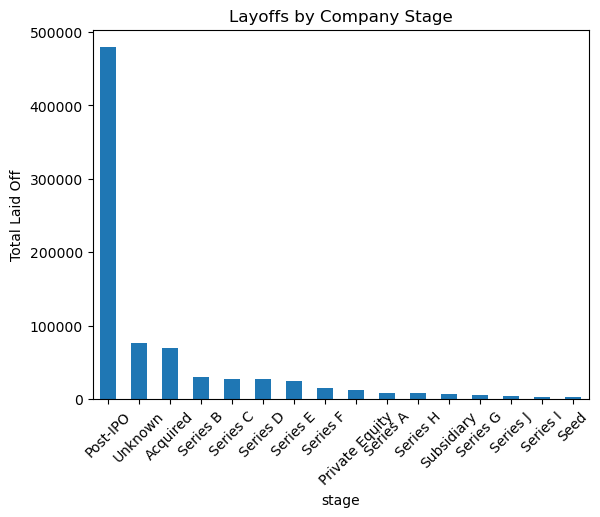

In [36]:
stage_layoffs = df.groupby("stage")["total_laid_off"].sum().sort_values(ascending=False)

stage_layoffs.plot(kind="bar")
plt.title("Layoffs by Company Stage")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

Layoffs are often concentrated in later-stage companies, suggesting that large-scale workforce reductions are more common in mature organisations adjusting to market conditions.

### Layoffs by Funding Category

Companies are grouped based on their funding levels to analyse whether financial backing influences layoffs.

This helps determine:
- Whether well-funded companies are more resilient
- Or if they conduct larger layoffs due to scaling adjustments

C:\Users\USER\AppData\Local\Temp\ipykernel_17104\1378736188.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  funding_layoffs = df.groupby("funding_category")["total_laid_off"].sum()


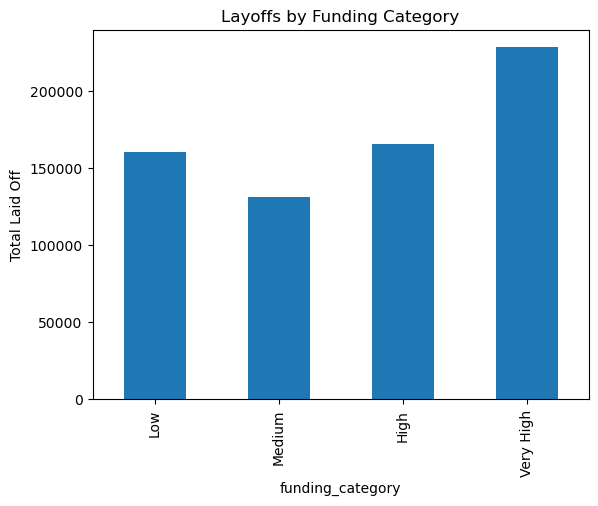

In [38]:
df["funding_category"] = pd.cut(
    df["funds_raised"],
    bins=[0, 50, 200, 1000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

funding_layoffs = df.groupby("funding_category")["total_laid_off"].sum()

funding_layoffs.plot(kind="bar")
plt.title("Layoffs by Funding Category")
plt.ylabel("Total Laid Off")
plt.show()

Even highly funded companies experience significant layoffs, suggesting that access to capital does not necessarily prevent workforce reductions during economic downturns.

### Layoffs by Company Stage and Funding

This combined analysis examines how company maturity and funding levels interact to influence layoffs.

It provides deeper insight into:
- Whether large layoffs are driven by well-funded late-stage companies
- The structural drivers behind workforce reductions

C:\Users\USER\AppData\Local\Temp\ipykernel_17104\3556997200.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


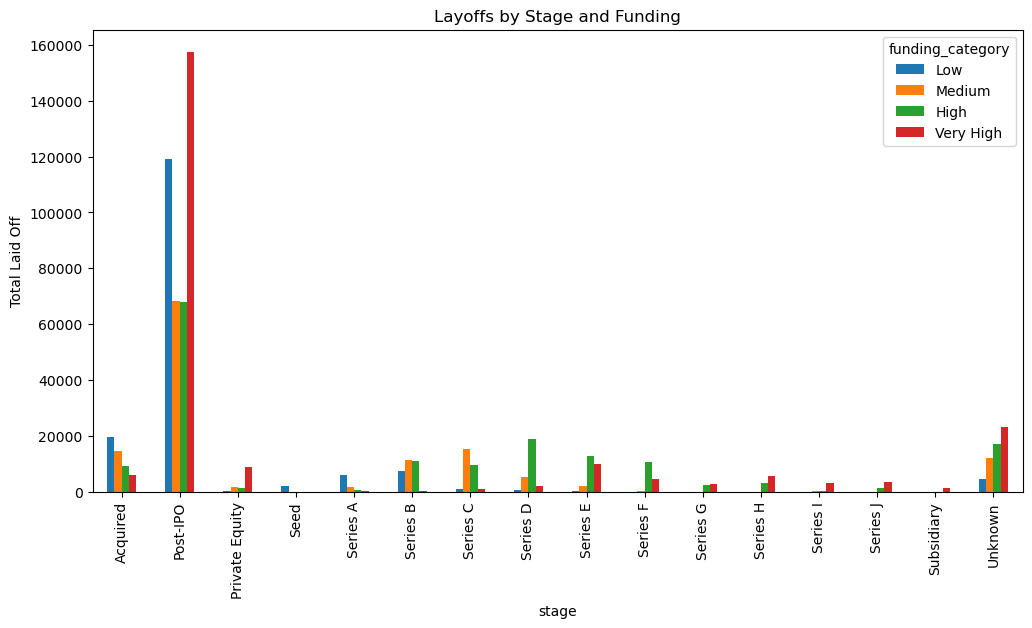

In [39]:
pivot = df.pivot_table(
    values="total_laid_off",
    index="stage",
    columns="funding_category",
    aggfunc="sum"
)

pivot.plot(kind="bar", figsize=(12,6))
plt.title("Layoffs by Stage and Funding")
plt.ylabel("Total Laid Off")
plt.show()

Large layoffs are often driven by well-funded, late-stage companies, indicating that layoffs may be a result of strategic restructuring rather than financial distress alone.

## Summary of Advanced Insights

The analysis reveals that layoffs are influenced by multiple factors including time, industry, geography, company stage, and funding levels.

Layoffs are not random but follow identifiable patterns, often driven by economic cycles, industry dynamics, and organisational restructuring.

In [40]:
df.to_csv("layoffs_cleaned.csv", index=False)